In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
# windows용 한글 폰트 오류 해결
from matplotlib import font_manager, rc
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc('font', family=font_name)

In [3]:
df = pd.read_excel("./data/시도별 전출입 인구수.xlsx")

In [4]:
df.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8808256,8487275,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226
2,NaN,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,2025358,1873188,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937
3,NaN,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,514502,519310,519334,508043,461042,478451,485710,507031,459015,439073
4,NaN,대구광역시,-,-,-,-,-,-,-,-,...,409938,398626,370817,370563,348642,351873,350213,351424,328228,321182


# 서울 -> 경기 인구 이동 그래프 (1970년 ~ 2017년)

In [5]:
df.shape

(325, 50)

In [6]:
df.dtypes

전출지별    object
전입지별    object
1970    object
1971    object
1972    object
1973    object
1974    object
1975    object
1976    object
1977    object
1978    object
1979    object
1980    object
1981    object
1982    object
1983    object
1984    object
1985    object
1986    object
1987    object
1988    object
1989    object
1990    object
1991    object
1992    object
1993    object
1994    object
1995    object
1996    object
1997    object
1998    object
1999    object
2000    object
2001    object
2002    object
2003    object
2004    object
2005    object
2006    object
2007    object
2008    object
2009    object
2010    object
2011    object
2012    object
2013    object
2014    object
2015    object
2016    object
2017    object
dtype: object

In [7]:
df.isnull().sum()

전출지별    306
전입지별      0
1970      0
1971      0
1972      0
1973      0
1974      0
1975      0
1976      0
1977      0
1978      0
1979      0
1980      0
1981      0
1982      0
1983      0
1984      0
1985      0
1986      0
1987      0
1988      0
1989      0
1990      0
1991      0
1992      0
1993      0
1994      0
1995      0
1996      0
1997      0
1998      0
1999      0
2000      0
2001      0
2002      0
2003      0
2004      0
2005      0
2006      0
2007      0
2008      0
2009      0
2010      0
2011      0
2012      0
2013      0
2014      0
2015      0
2016      0
2017      0
dtype: int64

- 엑셀 파일에서 병합된 셀을 데이터프레임에서 변환할 때 적절한 값을 찾지 못해 전출지별 열에 결측치 발생
    - 누락데이터 앞 행의 데이터로 채워야 함

In [9]:
df = df.ffill()

In [11]:
df.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8808256,8487275,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226
2,전국,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,2025358,1873188,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937
3,전국,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,514502,519310,519334,508043,461042,478451,485710,507031,459015,439073
4,전국,대구광역시,-,-,-,-,-,-,-,-,...,409938,398626,370817,370563,348642,351873,350213,351424,328228,321182


In [14]:
# 서울에서 다른 지역으로 이동한 데이터만 추출하여 정리
df_seoul = df[(df["전출지별"] == "서울특별시") & (df["전입지별"] != "서울특별시")]

In [15]:
df_seoul.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
19,서울특별시,전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,...,2083352,1925452,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423
21,서울특별시,부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,...,17353,17738,17418,18816,16135,16153,17320,17009,15062,14484
22,서울특별시,대구광역시,-,-,-,-,-,-,-,-,...,9720,10464,10277,10397,10135,10631,10062,10191,9623,8891
23,서울특별시,인천광역시,-,-,-,-,-,-,-,-,...,50493,45392,46082,51641,49640,47424,43212,44915,43745,40485
24,서울특별시,광주광역시,-,-,-,-,-,-,-,-,...,10846,11725,11095,10587,10154,9129,9759,9216,8354,7932


In [16]:
df_seoul = df_seoul.drop("전출지별", axis = 1)
df_seoul = df_seoul.rename({"전입지별" : "전입지"}, axis = 1)

In [17]:
df_seoul.head()

,전입지,1970,1971,1972,1973,1974,1975,1976,1977,1978,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
19,전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,3028911,...,2083352,1925452,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423
21,부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,29856,...,17353,17738,17418,18816,16135,16153,17320,17009,15062,14484
22,대구광역시,-,-,-,-,-,-,-,-,-,...,9720,10464,10277,10397,10135,10631,10062,10191,9623,8891
23,인천광역시,-,-,-,-,-,-,-,-,-,...,50493,45392,46082,51641,49640,47424,43212,44915,43745,40485
24,광주광역시,-,-,-,-,-,-,-,-,-,...,10846,11725,11095,10587,10154,9129,9759,9216,8354,7932


In [18]:
df_seoul = df_seoul.set_index("전입지")

In [19]:
df_seoul.head()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,3028911,2441242,...,2083352,1925452,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423
부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,29856,28542,...,17353,17738,17418,18816,16135,16153,17320,17009,15062,14484
대구광역시,-,-,-,-,-,-,-,-,-,-,...,9720,10464,10277,10397,10135,10631,10062,10191,9623,8891
인천광역시,-,-,-,-,-,-,-,-,-,-,...,50493,45392,46082,51641,49640,47424,43212,44915,43745,40485
광주광역시,-,-,-,-,-,-,-,-,-,-,...,10846,11725,11095,10587,10154,9129,9759,9216,8354,7932


In [20]:
df_seoul.index

Index(['전국', '부산광역시', '대구광역시', '인천광역시', '광주광역시', '대전광역시', '울산광역시', '세종특별자치시',
       '경기도', '강원도', '충청북도', '충청남도', '전라북도', '전라남도', '경상북도', '경상남도',
       '제주특별자치도'],
      dtype='object', name='전입지')

In [21]:
# 서울에서 경기도로 이동한 데이터만 선택
sr_gy = df_seoul.loc["경기도"]

In [22]:
sr_gy.head()

1970    130149
1971    150313
1972     93333
1973    143234
1974    149045
Name: 경기도, dtype: object

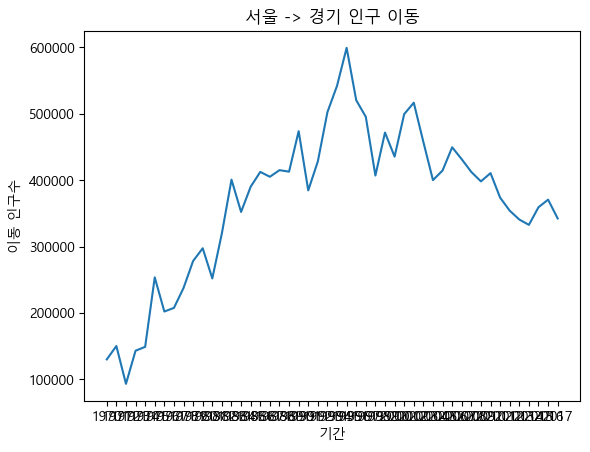

In [23]:
# 시리즈의 인덱스를 x축, 값을 y축으로 선 그래프 그리기
plt.plot(sr_gy)

plt.title("서울 -> 경기 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")
plt.show()

## 그래프 꾸미기

- 눈금 label이 들어갈 충분한 여유공간이 없으면 글씨가 겹치는 문제가 발생

- 해결 방법
    - figure() 로 공간을 만들기 위해 그래프의 가로 사이즈를 더 크게 설정
    - xticks() 로 x축 눈금 label을 90도 회전시켜서 글씨가 겹치지 않게 하기

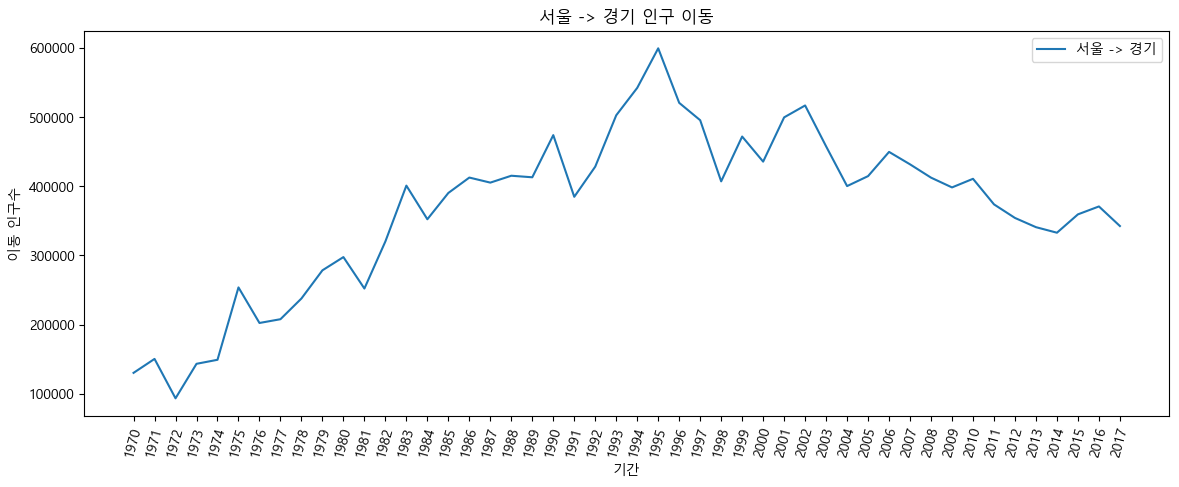

In [26]:
plt.figure(figsize = (14, 5))

plt.plot(sr_gy)

plt.xticks(rotation = 75)
plt.title("서울 -> 경기 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")
# 범례 표시
plt.legend(labels = ["서울 -> 경기"])
plt.show()

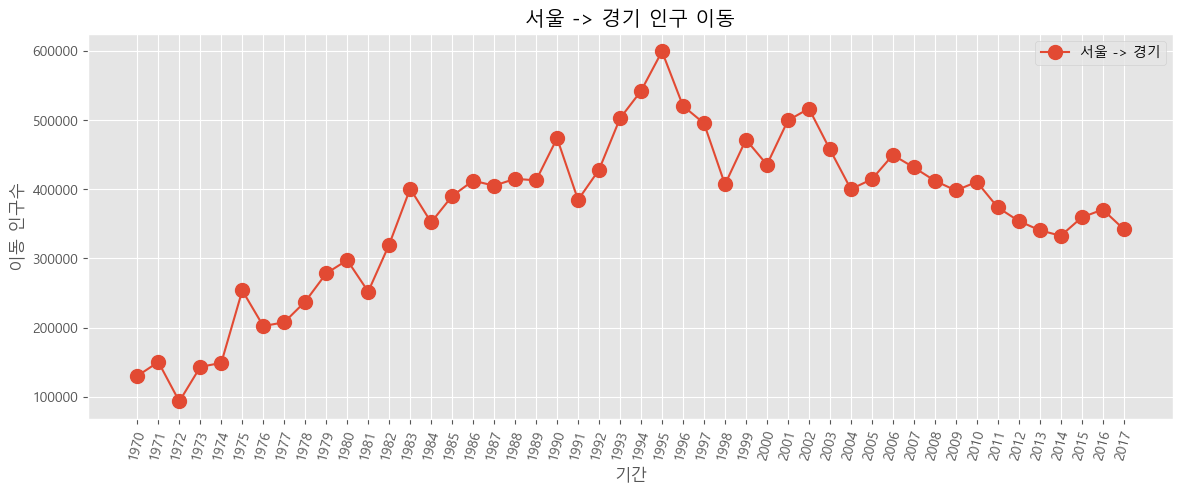

In [27]:
# 스타일 서식 지정
plt.style.use("ggplot")

plt.figure(figsize = (14, 5))

plt.plot(sr_gy, marker = "o", markersize = 10) # 마커 표시 추가

plt.xticks(rotation = 75)
plt.title("서울 -> 경기 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")
# 범례 표시
plt.legend(labels = ["서울 -> 경기"])
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10852\3770527625.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sr_gy.index, rotation = 75)


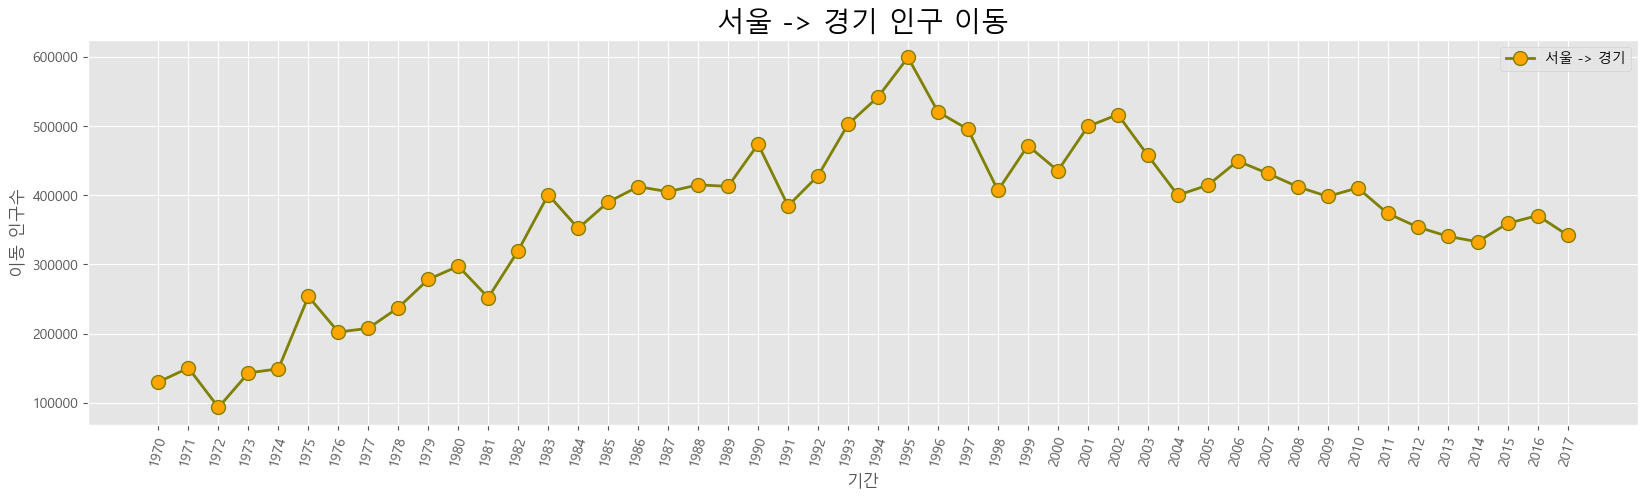

In [28]:
# 그래프 객체 생성 (figure에 1개의 서브 플롯을 생성)
fig = plt.figure(figsize = (20, 5))
ax = fig.add_subplot(1, 1, 1)

# axe 객체에 plot함수로 그래프 출력
ax.plot(sr_gy, marker = "o", markerfacecolor = "orange", markersize = 10, color = "olive", linewidth = 2,
        label = "서울 -> 경기")
ax.legend()

# 차트 제목
ax.set_title("서울 -> 경기 인구 이동", size = 20)

# 축 이름
ax.set_xlabel("기간", size = 12)
ax.set_ylabel("이동 인구수", size = 12)

# 눈금 라벨 지정 및 회전
ax.set_xticklabels(sr_gy.index, rotation = 75)

# 축 눈금 라벨 크기
ax.tick_params(axis = "both", labelsize = 10)

plt.show()

# 서울에서 충남, 경북, 강원도로 이동한 인구 데이터 시각화

In [29]:
df_seoul.head()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,3028911,2441242,...,2083352,1925452,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423
부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,29856,28542,...,17353,17738,17418,18816,16135,16153,17320,17009,15062,14484
대구광역시,-,-,-,-,-,-,-,-,-,-,...,9720,10464,10277,10397,10135,10631,10062,10191,9623,8891
인천광역시,-,-,-,-,-,-,-,-,-,-,...,50493,45392,46082,51641,49640,47424,43212,44915,43745,40485
광주광역시,-,-,-,-,-,-,-,-,-,-,...,10846,11725,11095,10587,10154,9129,9759,9216,8354,7932


In [30]:
df_seoul.index

Index(['전국', '부산광역시', '대구광역시', '인천광역시', '광주광역시', '대전광역시', '울산광역시', '세종특별자치시',
       '경기도', '강원도', '충청북도', '충청남도', '전라북도', '전라남도', '경상북도', '경상남도',
       '제주특별자치도'],
      dtype='object', name='전입지')

In [31]:
# 서울에서 충남, 경북, 강원도 이동한 인구 데이터 선택
df_3 = df_seoul.loc[["충청남도", "경상북도", "강원도"]]

In [32]:
df_3.head()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
충청남도,15954,18943,23406,27139,25509,51205,41447,43993,48091,45388,...,27458,24889,24522,24723,22269,21486,21473,22299,21741,21020
경상북도,11868,16459,22073,27531,26902,46177,40376,41155,42940,43565,...,15425,16569,16042,15818,15191,14420,14456,15113,14236,12464
강원도,9352,12885,13561,16481,15479,27837,25927,25415,26700,27599,...,23668,23331,22736,23624,22332,20601,21173,22659,21590,21016


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10852\255551813.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sr_gy.index, rotation = 75)


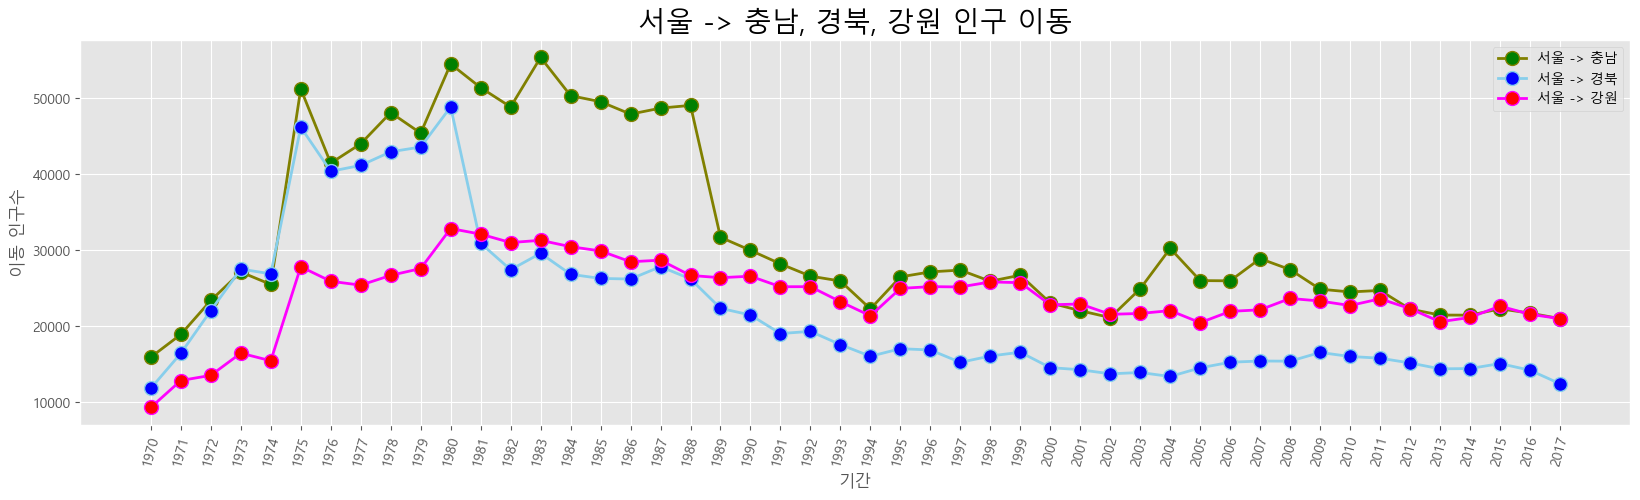

In [34]:
# 시각화
fig = plt.figure(figsize = (20, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(df_3.loc["충청남도"], marker = "o", markerfacecolor = "green", markersize = 10, color = "olive", linewidth = 2,
        label = "서울 -> 충남")
ax.plot(df_3.loc["경상북도"], marker = "o", markerfacecolor = "blue", markersize = 10, color = "skyblue", linewidth = 2,
        label = "서울 -> 경북")
ax.plot(df_3.loc["강원도"], marker = "o", markerfacecolor = "red", markersize = 10, color = "magenta", linewidth = 2,
        label = "서울 -> 강원")

ax.legend()

ax.set_title("서울 -> 충남, 경북, 강원 인구 이동", size = 20)

# 축 이름
ax.set_xlabel("기간", size = 12)
ax.set_ylabel("이동 인구수", size = 12)

# 눈금 라벨 지정 및 회전
ax.set_xticklabels(sr_gy.index, rotation = 75)

# 축 눈금 라벨 크기
ax.tick_params(axis = "both", labelsize = 10)

plt.show()

- 지리적으로 가까운 충남지역으로 이동한 인구가 다른 두 지역에 비해 많은 편
- 70 ~ 80년대에는 서울에서 지방으로 전출하는 인구가 많았으나 90년 이후로는 감소하는 패턴을 보임

## 면적 그래프(area plot)

- 각 열의 데이터를 선 그래프로 구현하는데, 선 그래프와 x축 사이의 공간에 색이 입혀짐

In [36]:
# 서울에서 충남, 경북, 강원, 전남으로 이동한 인구 데이터 선택
df_4 = df_seoul.loc[["충청남도", "경상북도", "강원도", "전라남도"]]
df_4 = df_4.T
df_4.head()

전입지,충청남도,경상북도,강원도,전라남도
1970,15954,11868,9352,10513
1971,18943,16459,12885,16755
1972,23406,22073,13561,20157
1973,27139,27531,16481,22160
1974,25509,26902,15479,21314


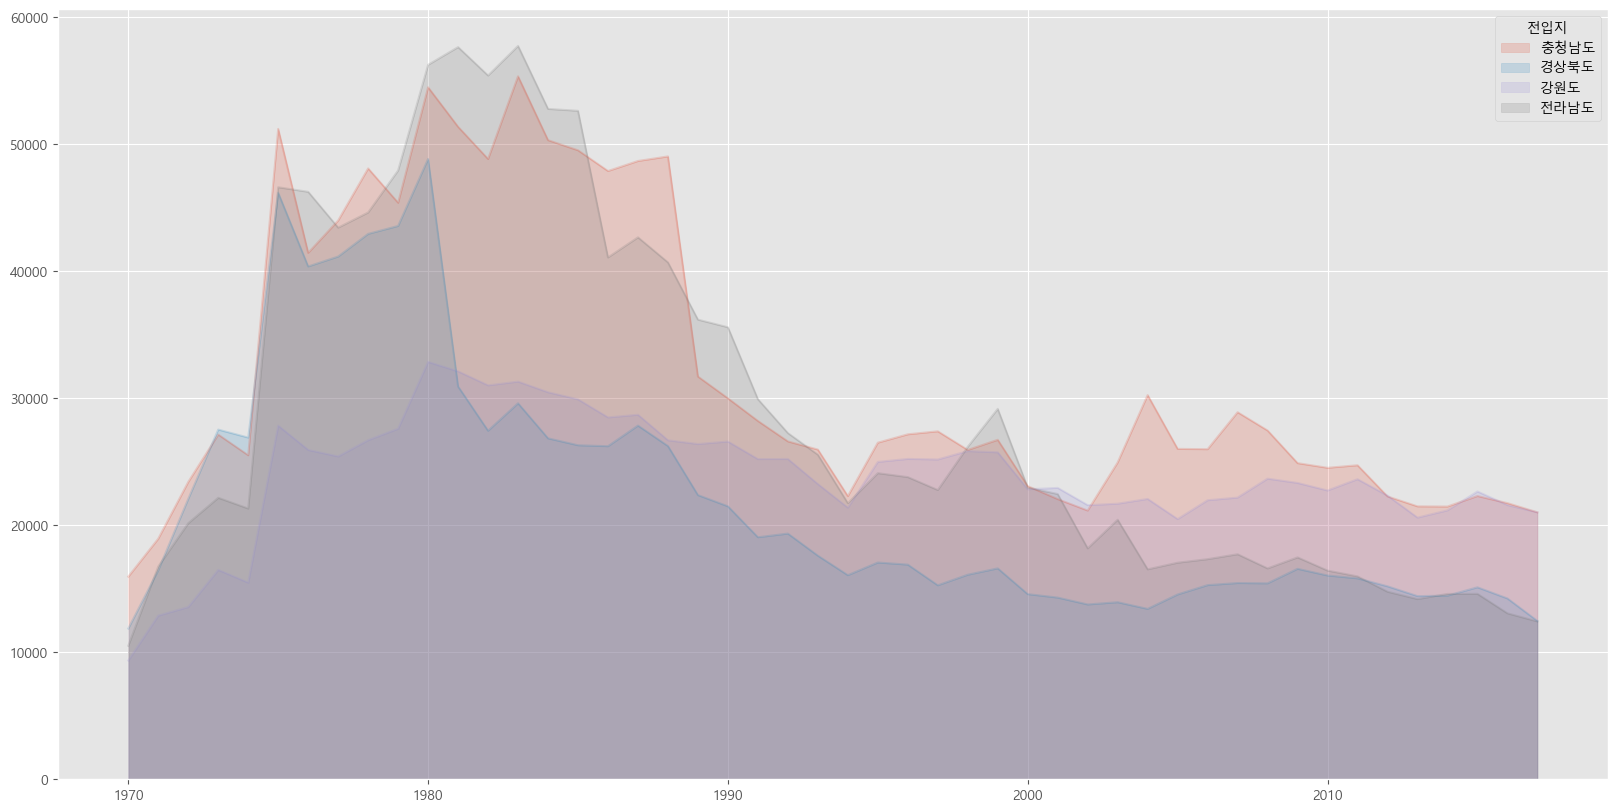

In [37]:
# 면적 그래프 그리기
df_4.plot(kind = "area", stacked = False, alpha = 0.2, figsize = (20, 10))

plt.show()

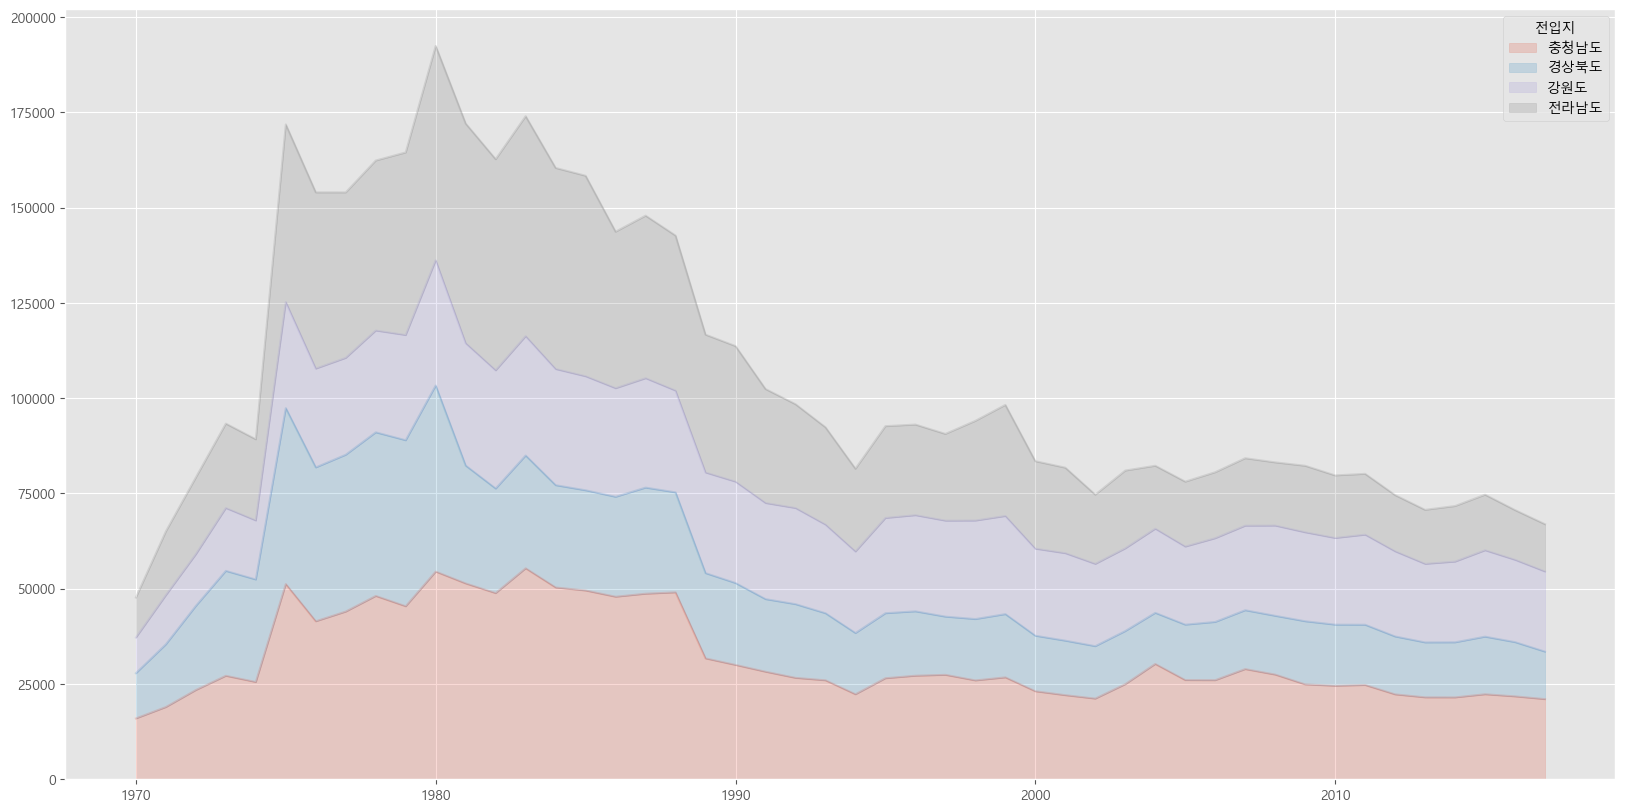

In [38]:
df_4.plot(kind = "area", stacked = True, alpha = 0.2, figsize = (20, 10))

plt.show()

## 막대 그래프

In [39]:
df_4.head()

전입지,충청남도,경상북도,강원도,전라남도
1970,15954,11868,9352,10513
1971,18943,16459,12885,16755
1972,23406,22073,13561,20157
1973,27139,27531,16481,22160
1974,25509,26902,15479,21314


In [40]:
df_4.index

Index(['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017'],
      dtype='object')

In [42]:
df_4 = df_4.loc["2010":]
df_4.head()

전입지,충청남도,경상북도,강원도,전라남도
2010,24522,16042,22736,16429
2011,24723,15818,23624,15974
2012,22269,15191,22332,14765
2013,21486,14420,20601,14187
2014,21473,14456,21173,14591


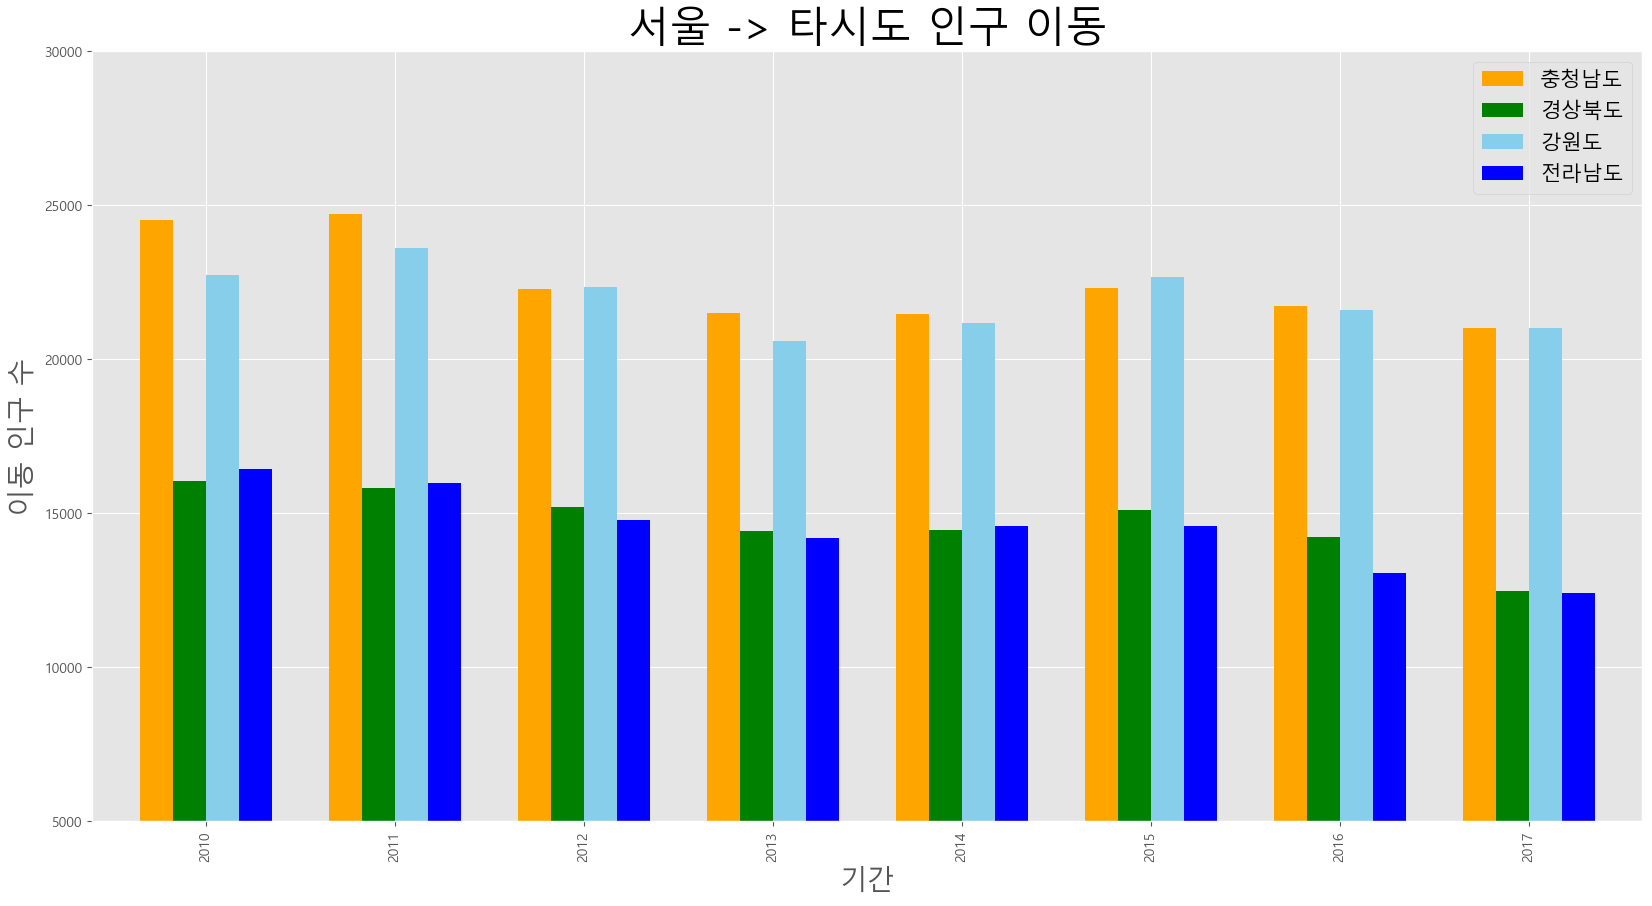

In [45]:
# 막대 그래프 그리기
df_4.plot(kind = "bar", figsize = (20, 10), width = 0.7, color = ["orange", "green", "skyblue", "blue"])

plt.title("서울 -> 타시도 인구 이동", size = 30)
plt.ylabel("이동 인구 수", size = 20)
plt.xlabel("기간", size = 20)
plt.legend(fontsize = 15)
plt.ylim(5000, 30000)

plt.show()

- 가로 막대 그래프는 각 변수 사이 값의 크기 차이를 설명하는데 적합

In [46]:
df_4.head()

전입지,충청남도,경상북도,강원도,전라남도
2010,24522,16042,22736,16429
2011,24723,15818,23624,15974
2012,22269,15191,22332,14765
2013,21486,14420,20601,14187
2014,21473,14456,21173,14591


In [48]:
total = df_4.sum(axis = 0)
total

전입지
충청남도    179533
경상북도    117740
강원도     175731
전라남도    116035
dtype: object

In [53]:
total = total.sort_values()
total

전입지
전라남도    116035
경상북도    117740
강원도     175731
충청남도    179533
dtype: object

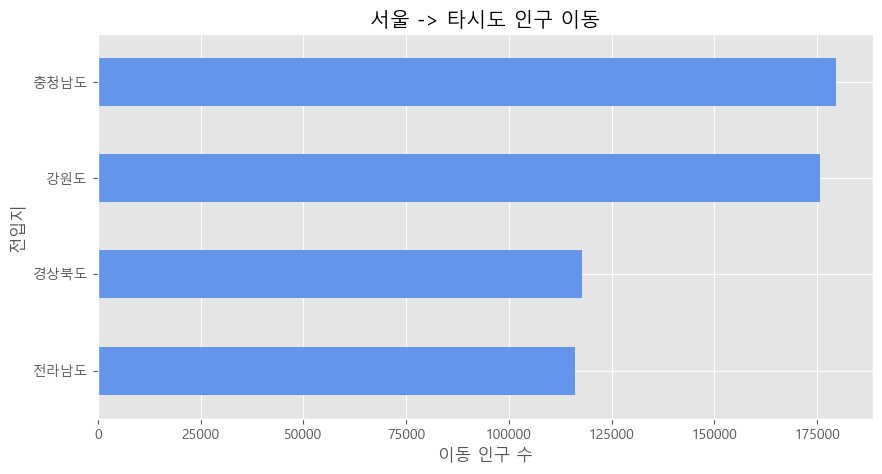

In [54]:
# 수평 막대 그래프 그리기
total.plot(kind = "barh", color = "cornflowerblue", width = 0.5, figsize = (10, 5))

plt.title("서울 -> 타시도 인구 이동")
plt.ylabel("전입지")
plt.xlabel("이동 인구 수")

plt.show()

- 2010 ~ 2017년에 서울에서 충청남도로 이동한 사람이 제일 많고 다음으로 강원도, 경상북도, 전라남도 순임

### 보조 축 활용

- 보조 축을 추가하여 2개의 y축을 갖는 그래프 그리기

In [55]:
df = pd.read_excel("./data/남북한발전전력량.xlsx")

In [58]:
df = df.loc[5:9]

In [61]:
df.columns

Index(['전력량 (억㎾h)', '발전 전력별', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016'],
      dtype='object')

In [64]:
df = df.drop("전력량 (억㎾h)", axis = 1)
df = df.set_index("발전 전력별")
df = df.T

In [65]:
df.head()

발전 전력별,합계,수력,화력,원자력
1990,277,156,121,-
1991,263,150,113,-
1992,247,142,105,-
1993,221,133,88,-
1994,231,138,93,-


In [67]:
# 증감율(변동률) 계산
df = df.rename(columns = {"합계" : "총발전량"})
df.head()

발전 전력별,총발전량,수력,화력,원자력
1990,277,156,121,-
1991,263,150,113,-
1992,247,142,105,-
1993,221,133,88,-
1994,231,138,93,-


In [69]:
df["총발전량 - 1년"] = df["총발전량"].shift(1)

In [70]:
df.head()

발전 전력별,총발전량,수력,화력,원자력,총발전량 - 1년
1990,277,156,121,-,None
1991,263,150,113,-,277
1992,247,142,105,-,263
1993,221,133,88,-,247
1994,231,138,93,-,221


In [74]:
df["증감율"] = ((df["총발전량"] / df["총발전량 - 1년"]) - 1) * 100

In [75]:
df.head()

발전 전력별,총발전량,수력,화력,원자력,총발전량 - 1년,증감율
1990,277,156,121,-,None,NaN
1991,263,150,113,-,277,-5.054152
1992,247,142,105,-,263,-6.08365
1993,221,133,88,-,247,-10.526316
1994,231,138,93,-,221,4.524887


C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


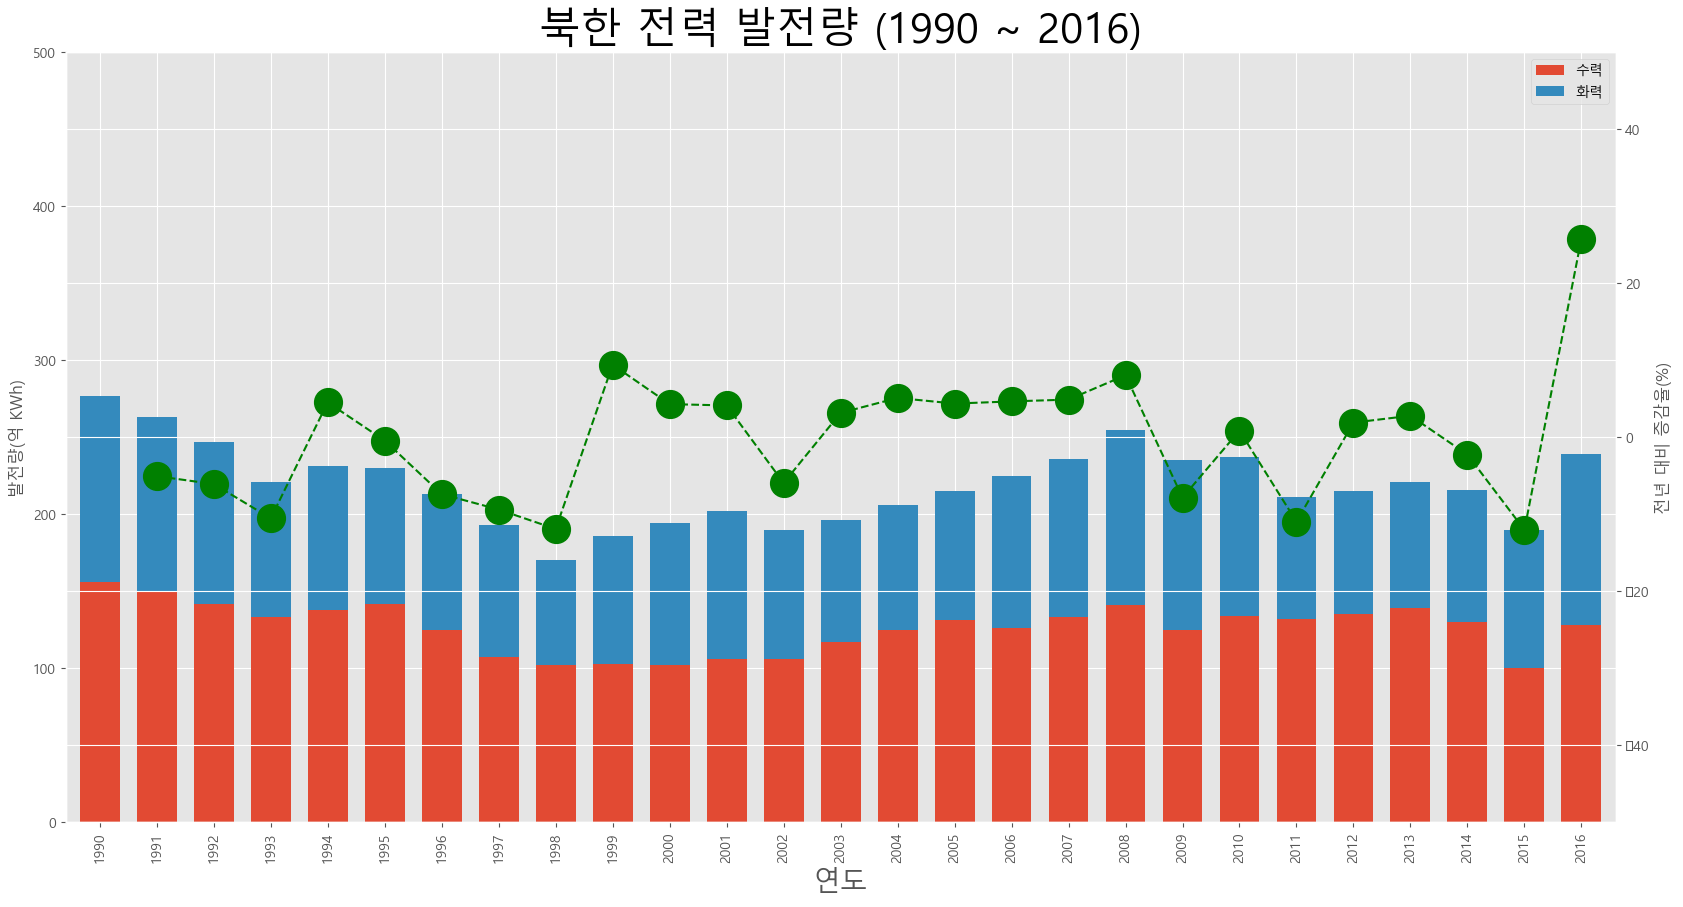

In [80]:
# 2축 그래프 그리기
ax1 = df[["수력", "화력"]].plot(kind = "bar", figsize = (20, 10), width = 0.7, stacked = True)
ax2 = ax1.twinx() # 원래 주어진 axis, x 를 공유하는 쌍둥이 axis
ax2.plot(df["증감율"], ls = "--", marker = "o", markersize = 20, color = "green", label = "전년대비 증감율(%)")

ax1.set_xlabel("연도", size = 20)
ax1.set_ylabel("발전량(억 KWh)")
ax2.set_ylabel("전년 대비 증감율(%)")

plt.title("북한 전력 발전량 (1990 ~ 2016)", size = 30)
ax1.legend()

ax1.set_ylim(0, 500)
ax2.set_ylim(-50, 50)

plt.show()

## 산점도

In [81]:
plt.style.use("default")

In [82]:
df = pd.read_csv("./data/auto-mpg.csv", header = None,
                 names = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model year",
                          "origin", "name"])

In [83]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


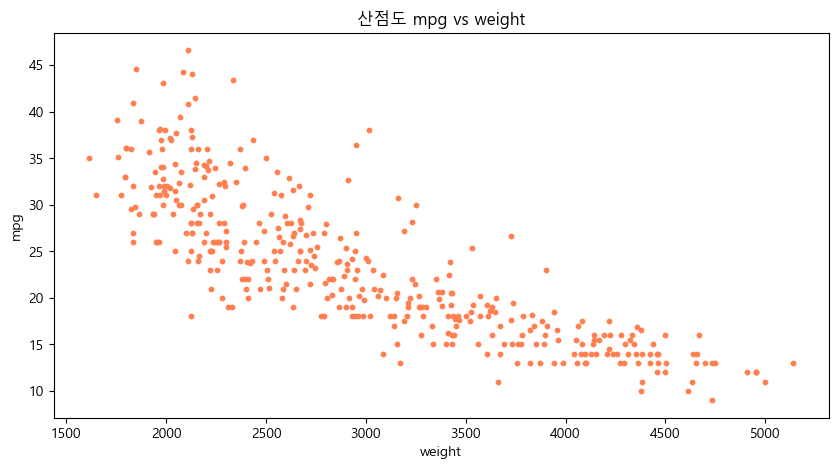

In [86]:
# 연비(mpg)와 차중(weight) 열에 대한 산점도
df.plot(kind = "scatter", x = "weight", y = "mpg", c = "coral", s = 10, figsize = (10, 5))
plt.title("산점도 mpg vs weight")
plt.show()

- cylinders 변수를 추가

In [87]:
df["cylinders"]

0      8
1      8
2      8
3      8
4      8
      ..
393    4
394    4
395    4
396    4
397    4
Name: cylinders, Length: 398, dtype: int64

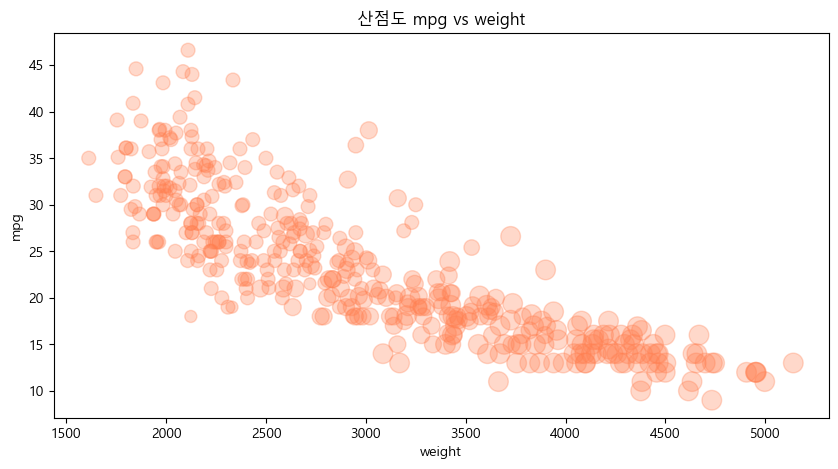

In [91]:
# cylinders의 상대적 비율을 계산
cylinders_size = df["cylinders"] / df["cylinders"].max() * 200

# 3개의 변수로 산점도 그리기
df.plot(kind = "scatter", x = "weight", y = "mpg", c = "coral", s = cylinders_size, figsize = (10, 5), alpha = 0.3)
plt.title("산점도 mpg vs weight")
plt.show()

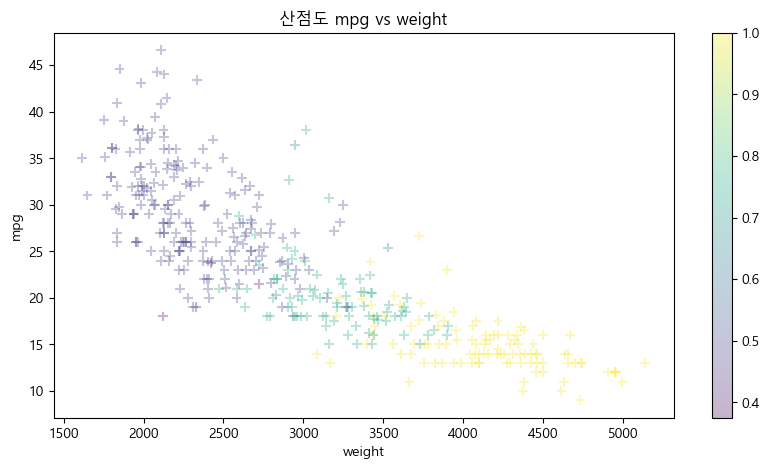

In [95]:
# cylinders의 상대적 비율을 계산
cylinders_size = df["cylinders"] / df["cylinders"].max()

# 3개의 변수로 산점도 그리기
df.plot(kind = "scatter", x = "weight", y = "mpg", c = cylinders_size, s = 50, figsize = (10, 5), alpha = 0.3,
        cmap = "viridis", marker = "+")
plt.title("산점도 mpg vs weight")

# 그래프를 그림 파일로 저장
plt.savefig("./scatter.png")
plt.savefig("./scatter_transparent.png", transparent = True)

plt.show()

## 히트맵

- 2개의 범주형 변수를 각각 x축, y축에 놓고 데이터를 행렬 형태로 분류하여 시각화

In [97]:
# titanic 데이터
titanic = sns.load_dataset("titanic")

In [98]:
# seaborn 스타일 테마 설정
sns.set_style("darkgrid")

In [99]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [102]:
# 피벗테이블로 범주형 변수를 각각 행, 열로 재구분하여 정리
table = titanic.pivot_table(index = ["sex"], columns = ["class"], aggfunc = "size")
table

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10852\3190160456.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = titanic.pivot_table(index = ["sex"], columns = ["class"], aggfunc = "size")


class,First,Second,Third
sex,,,
female,94,76,144
male,122,108,347


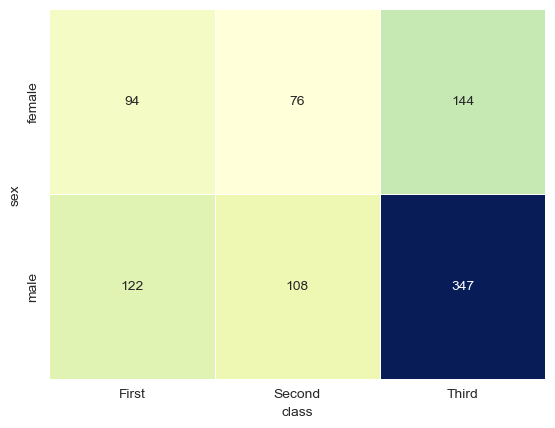

In [108]:
# 히트맵 그리기
sns.heatmap(table, # 데이터
            annot = True, fmt = "d", # 데이터 값 표시 여부, 정수형 포맷
            cmap = "YlGnBu", # 컬러 맵
            linewidth = .5, # 구분 선
            cbar = False) # 컬러 바 표시 여부

plt.show()